# **LIME for ECG Time Series Dataset Example**

**LIME (Local Interpretable Model-Agnostic Explanations)** — популярный модет в решении задачи интерпретации. Он основан на простой идее — приблизить прогнозы сложного оценщика (например, нейронной сети) простым — обычно линейной/логистической регрессией.

Применить LIME можно из коробки при помощи одноименной библиотеки [lime](https://github.com/marcotcr/lime). Однако, при применении LIME к, в частности, к временным рядам возникают особенности:

* При интерпретации нужно учесть, что временные ряды — это структурированные последовательности.
* Интерпретация проводится не по отдельным признакам, а по **сегментам времени**: насколько важен отрезок сигнала с 20-й по 30-ю миллисекунду?
* Для генерации соседних примеров нужно аккуратно вносить изменения в части сигнала, соответствующие сегментам: заменой на шум, среднее значение или другие методы.

поэтому в чистом виде lime для TimeSeries не всегда легко применить. И в этом туториале мы сделаем приближенение метода самостотельно! :)

А именно, вы:

* Узнаете, как использовать LIME для интерпретации моделей классификации сигналов ЭКГ;
* Разберете способ генерации осмысленных локальных возмущений;
* Обучите локальные модели, имитирующие поведение основной нейросети;
* Визуализируете, какие сегменты ЭКГ сигнала оказались наиболее значимыми для классификации.

Работать будем с **PyTorch + Scikit-learn**.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
#Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import f1_score
from torch.utils.data import DataLoader
from tqdm import tqdm
import torch
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset

from sklearn.metrics.pairwise import cosine_distances

### **Step 0. Loading and Preprocessing the Dataset**

Работать будем с набором данных про ЭКГ. А именно, в нашем распряжении будут записи ЭКГ по четырем классам (нормальный синусовый ритм, мерцательная аритмия, желудочковая тахикардия или мерцательная аритмия и инфаркт миокарда (сердечный приступ)). Более подробная информация про датасет [здесь](https://iopscience.iop.org/article/10.1088/1361-6579/abc960).

In [3]:
# Path to the dataset
file_path_train = 'https://github.com/SadSabrina/XAI-open_materials/blob/main/LIME_for_Time_Series/data/ecg_train.csv?raw=True'
file_path_test = 'https://github.com/SadSabrina/XAI-open_materials/blob/main/LIME_for_Time_Series/data/ecg_test.csv?raw=True'

# Training dataset
ecg_train = pd.read_csv(file_path_train, header=None)
# Testing dataset
ecg_test = pd.read_csv(file_path_test, header=None)

In [4]:
# Check info for train dataset
ecg_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188 entries, 0 to 187
Columns: 1640 entries, 0 to 1639
dtypes: float64(1639), int64(1)
memory usage: 2.4 MB


In [5]:
# Check info for test dataset
ecg_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Columns: 1640 entries, 0 to 1639
dtypes: float64(1639), int64(1)
memory usage: 512.6 KB


Проверим, в качестве классического шага, количество пропусков и бесконечных значений в данных и удалим объекты, которые могут нам помешать.

In [6]:
cols_with_nans_cnt = (ecg_train.isna().sum() > 0).sum()
cols_with_inf_cnt = np.isinf(ecg_train.values).sum()
samples_before = len(ecg_train)

ecg_train.dropna(inplace=True)

samples_after = len(ecg_train)

print(
f'Столбцов с пропусками: {cols_with_nans_cnt}\n\
Столбцов с бесконечными значениями: {cols_with_inf_cnt}\n\
Удалено объектов: {samples_before - samples_after}'
)

Столбцов с пропусками: 405
Столбцов с бесконечными значениями: 0
Удалено объектов: 1


In [ ]:
# For test data
cols_with_nans_cnt = (ecg_test.isna().sum() > 0).sum()
cols_with_inf_cnt = np.isinf(ecg_test.values).sum()
samples_before = len(ecg_test)

ecg_test.dropna(inplace=True)

samples_after = len(ecg_test)

print(
f'Столбцов с пропусками: {cols_with_nans_cnt}\n\
Столбцов с бесконечными значениями: {cols_with_inf_cnt}\n\
Удалено объектов: {samples_before - samples_after}'
)

Столбцов с пропусками: 0
Столбцов с бесконечными значениями: 0
Удалено объектов: 0


Поделим данные на X, y sets.

In [8]:
# Train data
ecg_train_x, ecg_train_y = ecg_train.drop(0, axis=1), ecg_train[0] - 1

In [9]:
# Test data
ecg_test_x, ecg_test_y = ecg_test.drop(0, axis=1), ecg_test[0] - 1

Поскольку задача классификации, проверим сбалансированность классов в обучающих данных и оценим её в тестовых — это позволит нам выбрать наиболее релевантную метрику для оценки.

In [10]:
# Check for Class Imbalance
print('Train Data imbalance results:')
print(ecg_train_y.value_counts(normalize=True))
print('Test Data imbalance results:')
print(ecg_test_y.value_counts(normalize=True))

Train Data imbalance results:
0
3    0.278075
1    0.245989
0    0.240642
2    0.235294
Name: proportion, dtype: float64
Test Data imbalance results:
0
1    0.325
2    0.300
3    0.250
0    0.125
Name: proportion, dtype: float64


В тестовых данных наблюдается дисбаланс, так что точность (accuracy) не отразит нам всего качества обучения модели при оценке на тестовой выборке. Будем использовать f1 score, с формулой:


$$
\text{F1} = 2 \cdot \frac{\text{precision} \cdot \text{recall}}{\text{precision} + \text{recall}}
$$

где:

* **Precision (точность):**

  $$
  \text{precision} = \frac{TP}{TP + FP}
  $$

  Доля объектов, предсказанных как положительные, которые действительно положительные.

* **Recall (полнота):**

  $$
  \text{recall} = \frac{TP}{TP + FN}
  $$

  Доля истинно положительных объектов, которые модель действительно обнаружила.

С точки зрения математики — $\text{F1}$ — просто гармоническое среднее двух значенений (precision и recall).


**Нюанс:** \\
Мы решаем задачу мультиклассовой классификации, поэтому метрику придётся немного модифицировать. А именно, вместо обычного F1-скор будем использовать **взвешенное среднее F1 (weighted F1-score)**, которое учитывает дисбаланс между классами.

Формально, если у нас $K$ классов, то:

$$
\text{F1}_{\text{weighted}} = \sum_{k=1}^{K} w_k \cdot \text{F1}_k,
$$

где:

* $\text{F1}_k$ — значение F1-метрики для $k$-го класса, рассчитанное по схеме «один против всех»;
* $w_k = \frac{n_k}{N}$ — доля объектов класса $k$ в выборке;
* $n_k$ — количество объектов класса $k$;
* $N = \sum_{k=1}^K n_k$ — общее количество объектов.

# **Building a CNN Model**

Теперь оформим модель, на основе которой будем решать задачу. На самом деле, в силу данных, можно было бы обойтись интерпретируемой моделью. Но так как цель туториала — практика в интерпретации черных ящиков — решим задачу при помощи сверточной сети.

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ECGCNN(nn.Module):
    def __init__(self, input_shape, num_classes):
        """
        input_shape: tuple time_steps, channels (exmaple 140, 1)
        num_classes: number of output classes
        """
        super(ECGCNN, self).__init__()
        time_steps, channels = input_shape

        self.conv1 = nn.Conv1d(in_channels=channels, out_channels=64, kernel_size=3)
        self.pool = nn.MaxPool1d(kernel_size=2)
        self.dropout = nn.Dropout(0.5)

        # Compute output length after conv and pooling
        conv_output_length = time_steps - 2  # kernel_size=3 reduces by 2
        pool_output_length = conv_output_length // 2  # MaxPool1d(pool_size=2)

        self.flattened_size = 64 * pool_output_length
        self.fc1 = nn.Linear(self.flattened_size, 100)
        self.fc2 = nn.Linear(100, num_classes)

    def forward(self, x):
        """
        x: Tensor of shape (batch_size, time_steps, channels)
        """
        if type(x) != torch.Tensor:
          x = torch.Tensor(x)

        x = x.permute(0, 2, 1)  # Change to (batch_size, channels, time_steps)
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = self.dropout(x)
        x = x.contiguous().view(x.size(0), -1)  # Flatten
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return torch.log_softmax(x, dim=1)  # Use CrossEntropyLoss, so no softmax here (pyTorch CrossEntropyLoss expects unbounded scores)

    def forward_probs(self, x):

      x = self.forward(x)
      return torch.exp(x)


In [12]:
# Build the Model
input_shape = (ecg_train_x.shape[1], 1)
num_classes = np.unique(ecg_train_y).shape[0]
model = ECGCNN(input_shape, num_classes)

In [13]:
# Train the CNN model
def train_ecg_model(model, train_dataset, val_dataset, num_epochs=10, batch_size=64, lr=1e-3, device='cuda' if torch.cuda.is_available() else 'cpu'):
    """
    Обучение модели ECGCNN с метриками точности и F1-score.

    Parameters:
        model: CNN model
        train_dataset: torch.utils.data.Dataset
        val_dataset: torch.utils.data.Dataset
        num_epochs: int
        batch_size: int
        lr: learning rate
        device: 'cuda' or 'cpu' if available.
    """
    model.to(device)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = torch.nn.CrossEntropyLoss()

    all_val_losses = []
    all_train_losses = []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        all_preds = []
        all_targets = []

        for X_batch, y_batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * X_batch.size(0)
            _, predicted = outputs.max(1)
            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(y_batch.cpu().numpy())

        train_loss = running_loss / len(train_dataset)
        train_acc = (np.array(all_preds) == np.array(all_targets)).mean()
        train_f1 = f1_score(all_targets, all_preds, average='weighted')

        all_train_losses.append(train_loss)

        # Validation
        model.eval()
        val_loss = 0.0
        val_preds = []
        val_targets = []
        with torch.no_grad():
            for X_val, y_val in val_loader:
                X_val = X_val.to(device)
                y_val = y_val.to(device)
                outputs = model(X_val)
                loss = criterion(outputs, y_val)
                val_loss += loss.item() * X_val.size(0)
                _, predicted = outputs.max(1)
                val_preds.extend(predicted.cpu().numpy())
                val_targets.extend(y_val.cpu().numpy())

        val_loss /= len(val_dataset)
        val_acc = (np.array(val_preds) == np.array(val_targets)).mean()
        val_f1 = f1_score(val_targets, val_preds, average='weighted')

        print(f"Epoch {epoch+1}/{num_epochs} — "
              f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f}, F1: {train_f1:.4f} | "
              f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}, F1: {val_f1:.4f}")

        all_val_losses.append(val_loss)

    plt.plot(all_train_losses, label='Train loss')
    plt.plot(all_val_losses, label='Val loss')
    plt.title('Loss plot')
    plt.legend()

In [14]:
class ECGDataset(Dataset):
    def __init__(self, x, y):
        self.x = torch.tensor(x, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

In [15]:
ecg_train_x = np.expand_dims(ecg_train_x, axis=2)

In [16]:
x_tr, x_val, y_tr, y_val = train_test_split(ecg_train_x, ecg_train_y.values, test_size=0.2, random_state=42)

train_dataset = ECGDataset(x_tr, y_tr)
val_dataset = ECGDataset(x_val, y_val)

Epoch 1/8: 100%|██████████| 3/3 [00:00<00:00,  4.15it/s]


Epoch 1/8 — Train Loss: 2.3626, Acc: 0.4295, F1: 0.4249 | Val Loss: 0.5118, Acc: 0.7895, F1: 0.7861


Epoch 2/8: 100%|██████████| 3/3 [00:00<00:00,  4.69it/s]


Epoch 2/8 — Train Loss: 0.3011, Acc: 0.8591, F1: 0.8641 | Val Loss: 0.3505, Acc: 0.8947, F1: 0.8986


Epoch 3/8: 100%|██████████| 3/3 [00:00<00:00,  4.99it/s]


...

Epoch 6/8 — Train Loss: 0.0177, Acc: 0.9933, F1: 0.9933 | Val Loss: 0.0799, Acc: 0.9737, F1: 0.9731


Epoch 7/8: 100%|██████████| 3/3 [00:00<00:00,  4.77it/s]


Epoch 7/8 — Train Loss: 0.0023, Acc: 1.0000, F1: 1.0000 | Val Loss: 0.0523, Acc: 0.9737, F1: 0.9741


Epoch 8/8: 100%|██████████| 3/3 [00:00<00:00,  4.80it/s]


Epoch 8/8 — Train Loss: 0.0032, Acc: 1.0000, F1: 1.0000 | Val Loss: 0.1193, Acc: 0.9737, F1: 0.9741


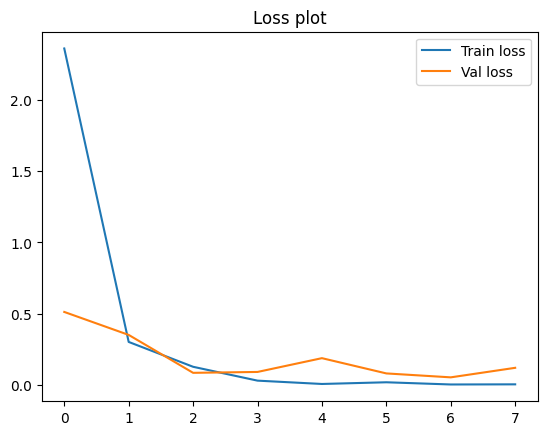

In [17]:
model = ECGCNN(input_shape=(ecg_train_x.shape[1], ecg_train_x.shape[2]), num_classes=len(set(ecg_train_y)))
train_ecg_model(model, train_dataset, val_dataset, num_epochs=8)

# ** Step 2. LIME for Time Seris Domain**

Теперь построим LIME. По определению, объяснение LIME — это **локальная интерпретируемая модель**, которая аппроксимирует поведение исходной сложной модели в **окрестности конкретного объекта** $x \in \mathbb{R}^d$ ($d$ — количество признаков в объекте).

Математически это задача оптимизации:

$$
\xi(x) = \arg\min_{g \in \mathcal{G}} \; \mathcal{L}(f, g, \pi_x) + \Omega(g)
$$

где:

* $f$ — сложная (исходная) модель, например нейросеть;
* $g \in \mathcal{G}$ — интерпретируемая модель (обычно линейная);
* $\pi_x(z)$ — вес, отражающий близость объекта $z$ к $x$; обычно вычисляется как:

  $$
  \pi_x(z) = \exp\left(-\frac{D(x, z)^2}{\sigma^2}\right)
  $$

  где $D$ — расстояние (например, косинусное или DTW), $\sigma$ — ширина ядра;
* $\mathcal{L}(f, g, \pi_x)$ — локальная функция потерь, измеряющая насколько хорошо $g$ приближает $f$ в окрестности $x$ — мы будем брать MSE;
* $\Omega(g)$ — мера сложности интерпретируемой модели (например, число ненулевых коэффициентов).

На практике, чтобы использовать эту формулу, нам нужны:

1. Конкретное наблюдение $x$ - его будем объяснять;
2. То, что мы будем считать за признаки во временном ряду (в нашем случае семгенты временного ряда);
4.  Окрестность —  множество наблюдений $z_1, \dots, z_N$ вокруг $x$;
5. Прогнозы — $f(z_i)$ на вариантах из полученной окресности;
6. Обученная интерпретируемая модель $g$ на точках из окресности (обученная с учётом весов $\pi_x(z_i)$), веса которой и будут отражать важность;



**Шаг 1. Конкретное наблюдение**

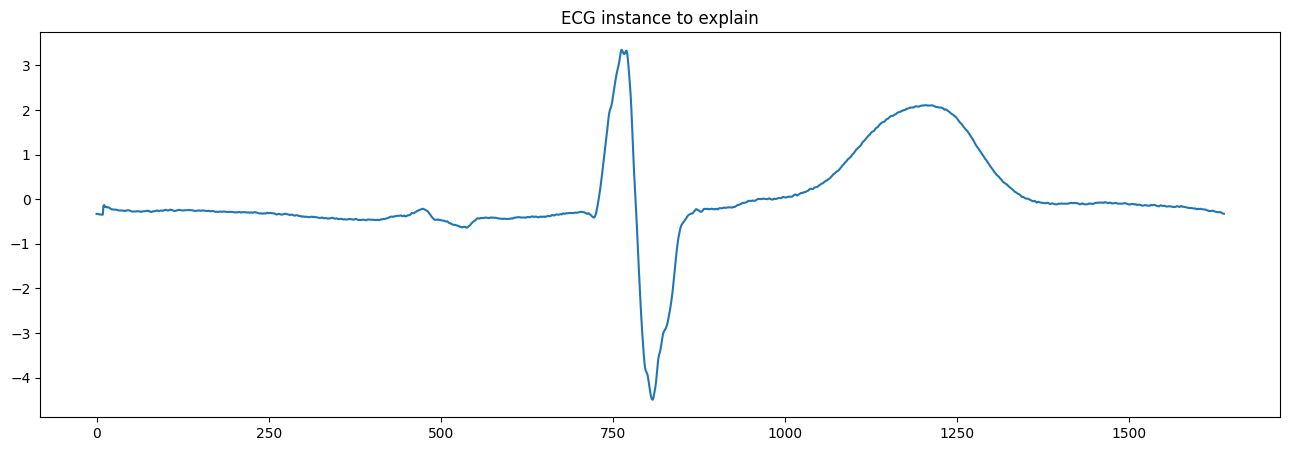

In [18]:
idx_ecg = 11                         # сhoose interested index from rows
instance_ecg = ecg_test_x.iloc[idx_ecg, :].values     # extract the selected instance from the test dataset

plt.figure(figsize=(16, 5))
plt.plot(instance_ecg)
plt.title('ECG instance to explain');

In [19]:
# Predict the class of the selected signal by trained model
probability_vector = model.forward_probs(torch.Tensor(np.expand_dims(instance_ecg.reshape(1, -1), axis=2)))

print("Probability vector of the selected instance:", probability_vector)

Probability vector of the selected instance: tensor([[9.0003e-09, 2.4549e-02, 9.7471e-01, 7.4185e-04]],
       grad_fn=<ExpBackward0>)


In [20]:
# class labels
class_labels = [0, 1, 2, 3]

predicted_class = torch.argmax(probability_vector).item()

print("Available classes:", class_labels)
print("Predicted Class for the selected instance:", predicted_class)


Available classes: [0, 1, 2, 3]
Predicted Class for the selected instance: 2


**Шаг 2. Получение сегментов-признаков.** \

Методом "пристального взгляда" подберем количество сегментов. Более правильный и формальный способ — подбирать количество сегментов в зависимости от природы сигнала.

Сегменты получим простым образом — нарезкой ряда на равные кусочки. А именно, для ряда $T$ с временными шагами $t_0, t_1, \dots, t_L$ мы делим его на $K$ отрезков фиксированной длины:

$$
l = \left\lfloor \frac{L}{K} \right\rfloor
$$

где $l$ — длина одного сегмента.

Затем мы строим индексы границ отрезков следующим образом:

$$
\text{Segment}_i = T[t_{i \cdot l} : t_{(i+1) \cdot l}], \quad i = 0, \dots, K-2
$$

Где последний сегмент может включать "хвост":

$$
\text{Segment}_{K-1} = T[t_{(K-1) \cdot l} : t_L]
$$

Таким образом, даже если длина ряда $L$ не делится на $K$ нацело, последний сегмент корректно включит все оставшиеся точки.


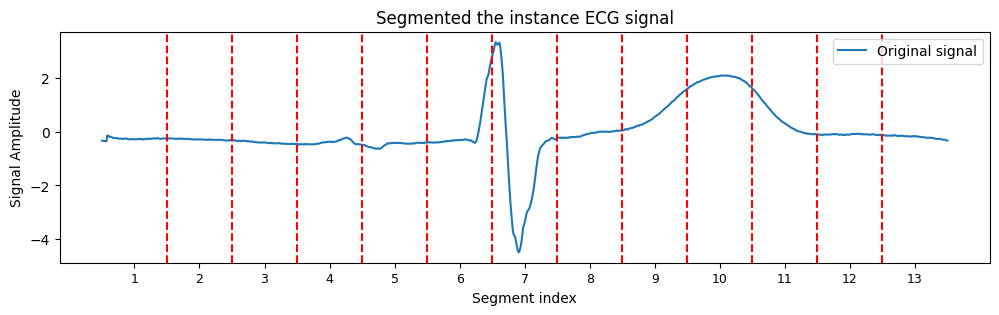

In [21]:
L = len(instance_ecg) # TS length
K = 13 # number of slices

l = L // K # slice width

# Segment start points
segment_edges = [i * l for i in range(K)] + [L]
# Segment centers
segment_centers = [(segment_edges[i] + segment_edges[i+1]) // 2 for i in range(K)]
# Segment labels
segment_labels = [f'{i+1}' for i in range(K)]

# Plot segmented instance
plt.figure(figsize=(12, 3))
plt.plot(instance_ecg, label='Original signal')

for i in range(1, K):
  plt.axvline(x=i*l, color='r', linestyle='--')

plt.xticks(ticks=segment_centers, labels=segment_labels, fontsize=9)
plt.title('Segmented the instance ECG signal')
plt.xlabel('Segment index')
plt.ylabel('Signal Amplitude')
plt.legend()
plt.show()

**Шаг 3. Генерация наблюдений в окресности.**

Будем генерировать наблюдения из окресности следующим образом. Для изначального наблюдения $x$ будем выбирать случайные номера сегментов $k$, и вносить в них изменения по одной из трех стратегий:

- "mean" — меняем значения сегмента на среднее по сегменту;
- "noise" — меняем значения сегмента на значения из нормального распределения, со средним и стандартным отклонением по сегменту;
- "zero" — просто обнуляем значения сегмента

Все замены будем проводить по кусочкам $Segment_i=T[t_{il}, t_{(i_1)l}]$

In [22]:
# Segment slices function
def split_series(series, num_slices):

    length = series.shape[0]
    slice_len = int(np.ceil(length / num_slices))
    return [(i * slice_len, min((i + 1) * slice_len, length)) for i in range(num_slices)]

slices = split_series(instance_ecg, 13)


def generate_perturbations(series, slices, num_samples, replacement="mean", pertub_power=0.2):
    perturbed = []
    masks = []
    for _ in range(num_samples):
        mask = np.ones(len(slices), dtype=int)
        idx_to_perub = np.random.choice(len(slices), size=int(len(slices)*pertub_power), replace=False) # менять за раз будем pertub_power% от всех кусочков
        mask[idx_to_perub] = 0

        copy = series.copy()
        for i in idx_to_perub:
            start, end = slices[i]
            if replacement == "mean":
                copy[start:end] = np.mean(series[start:end])
            elif replacement == "zero":
                copy[start:end] = 0
            elif replacement == "noise":
                copy[start:end] = np.random.normal(series[start:end].mean(), series[start:end].std(), end - start) #.reshape(1, -1)
        perturbed.append(copy)
        masks.append(mask)

    return np.array(perturbed), np.array(masks)


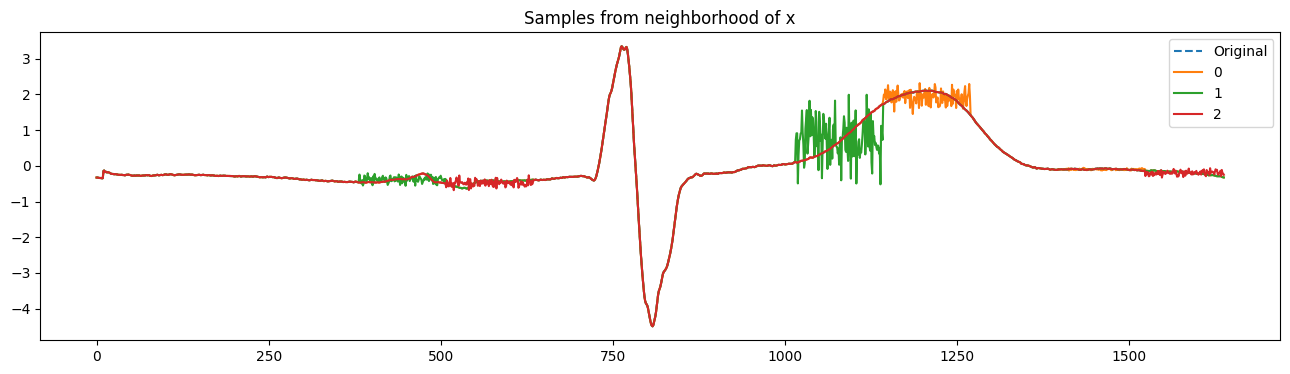

In [23]:
np.random.seed(42)
pertub, masks = generate_perturbations(instance_ecg, slices, 500, replacement="noise", pertub_power=0.2)

plt.figure(figsize=(16, 4))
plt.plot(instance_ecg, label='Original', linestyle='--')
[plt.plot(pertub[i], label=f'{i}') for i in range(0, 3)]
plt.legend()
plt.title('Samples from neighborhood of x');

Обратите внимание, на этом шаге мы получими маски. Для обучения интерпретируемой модели набор данных будет представлен бинарными признаками для каждого сегмента. Признак равен 1, если соответствующий сегмент включен, и 0, если он был искажен. Такой подход используется также при реализации LIME для [текстовых данных](https://christophm.github.io/interpretable-ml-book/lime.html?utm_source=chatgpt.com).

**Шаг 4. Обучение интерпретируемой модели в окресности.** \
Чтобы обучить модель будем, вместо решения исходной задачи, решать задачу обеспечения *похожести* интерпретируемой модели на модель-черный ящик. Для этого будем обучать модель давать прогнозы такие же, какими их дает исходная модель.

Обучать модель будем в соответвии с важностью наблюдения. А именно, чем ближе он к исходному объекту, тем весомее он должен быть при обучении.

In [24]:
# Probabilities for all observations from the neighborhood
probs = np.exp(model(np.expand_dims(pertub, axis=2)).detach().numpy())

# Calculate the distances
distances = cosine_distances(pertub, instance_ecg.reshape(1, -1)).ravel()

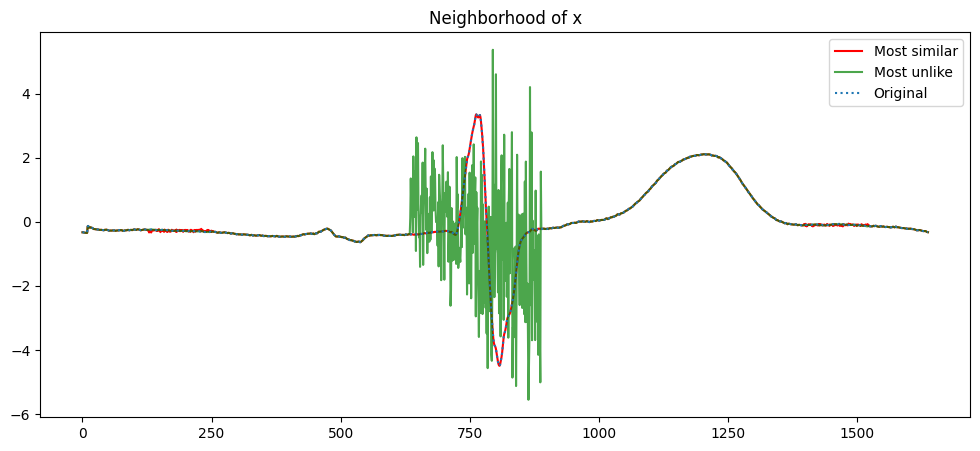

In [25]:
# Let's look at the nearest and the farthest object

similar_inst_idx = np.argmin(distances)
most_similar = pertub[similar_inst_idx]

unlike_inst_idx = np.argmax(distances)
most_unlike = pertub[unlike_inst_idx]

plt.figure(figsize=(12, 5))
plt.plot(most_similar, label='Most similar', color='r')
plt.plot(most_unlike, label='Most unlike', alpha=0.7, color='g')
plt.plot(instance_ecg, label='Original', linestyle=':')
plt.legend()
plt.title('Neighborhood of x');

In [26]:
from sklearn.linear_model import Ridge
import numpy as np

def train_lime_ridge(perturbations, predictions, distances, target_class, alpha=1.0, kernel_width=0.25):
    """
    Train interpretable model (Ridge)

    Parameters:
        perturbations (np.array): features [N x K], mask
        predictions (np.array): матрица [N x C], вероятности классов
        distances (np.array): длина N, расстояния до оригинала
        target_class (int): индекс класса, который объясняется
        alpha (float): коэффициент регуляризации Ridge
        kernel_width (float): ширина ядра для весов

    Returns:
        (weights, intercept, score): коэф. модели, свободный член, R^2 на подмножестве
    """
    # LIME exponential kernel
    weights = np.exp(- (distances ** 2) / (kernel_width ** 2))

    # target
    y = predictions[:, target_class]

    # simple Ridge-regression train
    model = Ridge(alpha=alpha)
    model.fit(perturbations, y, sample_weight=weights)

    return model.coef_, model.intercept_, model.score(perturbations, y, sample_weight=weights)

w, b, score = train_lime_ridge(masks, probs, distances, 0, alpha=.8)

/tmp/ipython-input-27-1003460461.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap(cmap)(norm(weights))


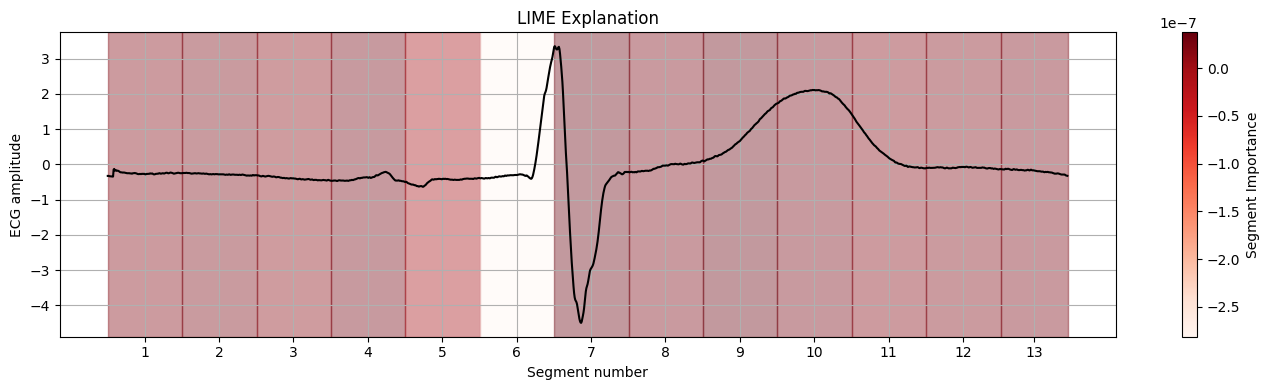

In [27]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

def visualize_segment_weights(series, slices, weights, title='LIME Explanation', cmap='Reds'):
    """
    Визуализирует важность сегментов поверх временного ряда.

    Parameters:
        series (np.array): временной ряд (shape: [T])
        slices (list of tuples): список (start_idx, end_idx) сегментов
        weights (np.array): важности для каждого сегмента
        title (str): заголовок графика
        cmap (str): цветовая карта для заливки сегментов
    """
    assert len(slices) == len(weights), "Количество весов должно соответствовать количеству сегментов"

    norm = plt.Normalize(vmin=min(weights), vmax=max(weights))
    colors = cm.get_cmap(cmap)(norm(weights))

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(series, color='black', linewidth=1.5, label='Time Series')

    segment_centers = []
    segment_labels = []

    for i, ((start, end), color) in enumerate(zip(slices, colors)):
        ax.axvspan(start, end, color=color, alpha=0.4)
        center = (start + end) // 2
        segment_centers.append(center)
        segment_labels.append(f'{i+1}')

    # Добавим подписи по оси X — номера сегментов
    ax.set_xticks(segment_centers)
    ax.set_xticklabels(segment_labels, rotation=0)
    ax.set_xlabel('Segment number')

    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    plt.colorbar(sm, label='Segment Importance', ax=ax)
    plt.title(title)
    plt.ylabel('ECG amplitude')
    plt.grid(True)
    plt.tight_layout()
    plt.show()


visualize_segment_weights(instance_ecg, slices, w, title='LIME Explanation');

Чтобы чуть точнее (и сохрасованно с LIME-plots в библиотеках) взглянуть на важность, можно оформить столбчатую диаграмму.  

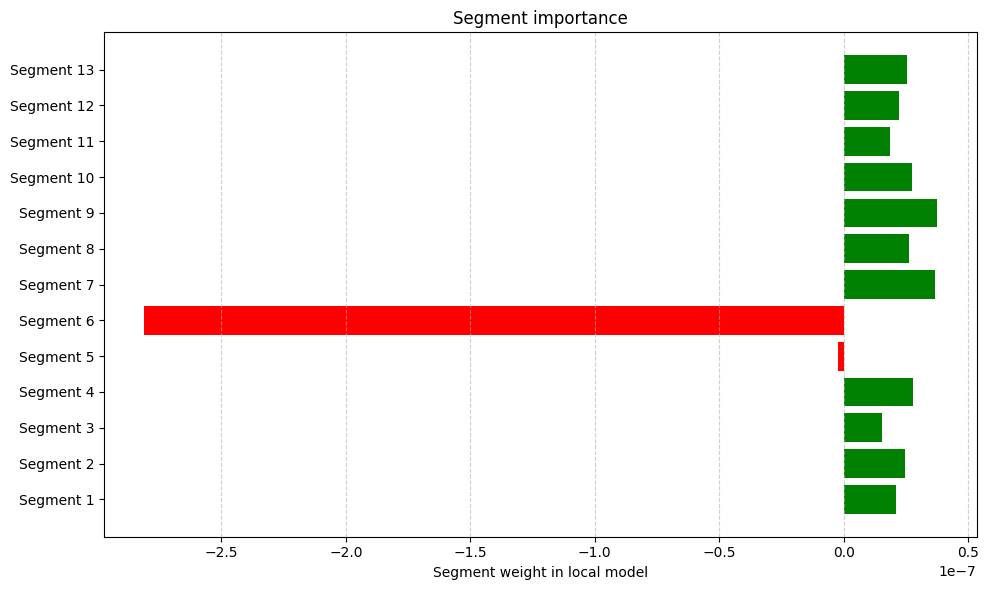

In [28]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['green' if val >= 0 else 'red' for val in w]
segment_labels = [f'Segment {i+1}' for i in range(len(w))]

ax.barh(range(len(w)), w, color=colors)
ax.set_yticks(range(len(w)))
ax.set_yticklabels(segment_labels)
ax.set_xlabel('Segment weight in local model')
ax.set_title('Segment importance')
plt.grid(True, axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Готово! Спасибо, друзья! \\

В этом туториале мы рассмотрели применение метода **LIME** к задаче интерпретации модели классификации временных рядов на примере ЭКГ-сигналов. Для этого:

* обучили простую сверточную нейросеть для распознавания классов ЭКГ;
* реализовали механизм генерации локальных объяснений с помощью сегментации временного ряда;
* построили визуализации важности сегментов как поверх сигнала, так и в виде диаграммы весов.

LIME позволил нам локально аппроксимировать поведение модели и оценить, какие части сигнала оказали наибольшее влияние на её предсказание.

Несмотря на простоту реализации, LIME остаётся мощным и гибким инструментом для анализа моделей с любыми типами входных данных. Однако стоит помнить, что качество интерпретации зависит от выбора параметров (например, числа сегментов) и стратегии генерации "окрестности" (можете поиграть также с параметрами функций  и оценить насколько пошатнутся веса).

Основные материалы туториала:
[1](https://github.com/mdhabibi/LIME-for-Time-Series/tree/main?tab=readme-ov-file), [2](https://github.com/emanuel-metzenthin/Lime-For-Time/tree/master), [3](https://arxiv.org/abs/1602.04938).

### **Новые туториалы:**

За ними всегда жду вас в [дата-блоге](https://t.me/jdata_blog)! Обещаю публиковать материалы чаще! :)

Со всем самым добрым, \\
Ваш Дата-автор!